## PyTorch Workflow 2 (Full Workflow Go-Through)
In this notebook we will construct a Multiple Linear Regression model going through the entire workflow of training, validating, and testing the model on a real-world [student performance dataset](https://www.google.com/url?q=https%3A%2F%2Fwww.kaggle.com%2Fdatasets%2Fgrandmaster07%2Fstudent-exam-performance-dataset-analysis) containing over 6,000student records of socioeconomic, behavioural, and academic predictors of exam performance. 

We seek to explore which student factors (study hours, attendance, sleep, prior performance, socioeconomic background, etc.) are statistically significant predictors of exam score.

In [18]:
## Standard Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## ML
import torch
from torch import nn # PyTorch regression
from scipy import stats
import statsmodels.api as sm # OLS Regression

## ML Training & Evaluation
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

seed= 42
np.random.seed(seed)

In [19]:
## Device agnostic code
device= 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device {device}')

Using device cpu


In [20]:
## Load the dataset
students= pd.read_csv('https://raw.githubusercontent.com/vicdotcom/My-Datasets/refs/heads/main/StudentPerformanceFactors.csv')

print(f'Dataset Shape: {students.shape}')
print(f'\nNull values per Column')
print(students.isna().sum()[students.isna().sum()> 0])
students.head()

Dataset Shape: (6607, 20)

Null values per Column
Teacher_Quality             78
Parental_Education_Level    90
Distance_from_Home          67
dtype: int64


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


Columns with null elements are categorical. 

In [21]:
## Info on dataset
students.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [22]:
## Dataset statistics (numerical columns)
students.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


##### Dataset Description

The **Student Performance Factors** dataset comprises 6,607 student records and 20 variables collected to understand the determinants of academic performance. The dataset includes a mix of continuous and categorical predictors spanning:

- **Behavioural factors:** `Hours_Studied`, `Sleep_Hours`, `Physical_Activity`, `Extracurricular_Activities`
- **Academic factors:** `Attendance`, `Previous_Scores`, `Tutoring_Sessions`, `Learning_Disabilities`
- **Socioeconomic factors:** `Family_Income`, `Parental_Involvement`, `Parental_Education_Level`, `Access_to_Resources`
- **Institutional factors:** `School_Type`, `Teacher_Quality`, `Internet_Access`
- **Social factors:** `Peer_Influence`, `Motivation_Level`
- **Demographic:** `Gender`, `Distance_from_Home`

----

- **Response Variable:** `Exam_Score` — a continuous integer score.

### Quick EDA
We can start by checking the distribution of the numerical predictors to guide how they will be transformed. When numerical features have various scales but follow a Gaussian (Normal) or Gaussian-like distribution, we implement stndardization (z-score normalization) via a `StandardScaler()` otherwise if they dont follow a Gaussian/Gaussian-like distribution we implement MinMax scaling (normalization) via a `MinMaxScaler()`. While it is not a very strcit requirement to transform data this way (most practictioners use a `StandardScaler()` on all features for simplicity). It is good practice to do so especially for linear models that are sensitive to scale.

In [23]:
## Numerical columns
numerical_cols= students.select_dtypes(['int', 'float'])
print(numerical_cols.shape)
numerical_cols.head()

(6607, 7)


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
0,23,84,7,73,0,3,67
1,19,64,8,59,2,4,61
2,24,98,7,91,2,4,74
3,29,89,8,98,1,4,71
4,19,92,6,65,3,4,70


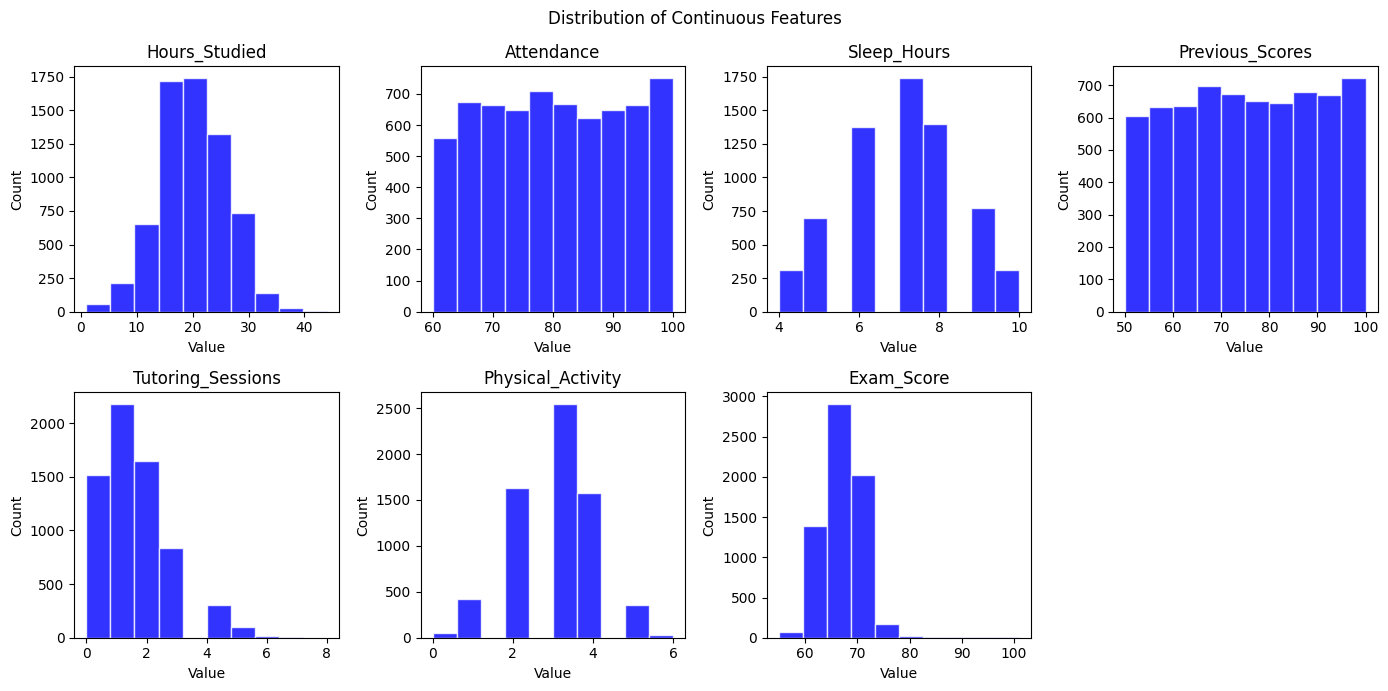

In [24]:
## Distribution of numerical columns
fig, axes= plt.subplots(2, 4, figsize= (14, 7))
axes= axes.flatten()

for i, col in enumerate(numerical_cols.columns):
    axes[i].hist(numerical_cols[col], bins= 10, color= 'blue', 
                 edgecolor= 'white', alpha= 0.8)
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

# Hide remaining empty axes
for j in range(len(numerical_cols.columns), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Continuous Features')
plt.tight_layout()

`Hours_Studied`, `Sleep_Hours` and `Physical_Activity` have a Gaussian/Gaussian-like distribution and will therefore be transformed via standardization while `Tutoring_Sessions`, `Attendance` and `Previous_Scores` show no Gaussian-like distribution and will therefore be scaled

On assessing outliers, given the educational context, no outliers are removed. Extreme values in study hours, attendance, or exam scores represent genuine student variation and are therefore deemed realistic. (i.e- Exam score range from around 55 to 100, some students can study exceptionally hard while others not at all/very little)

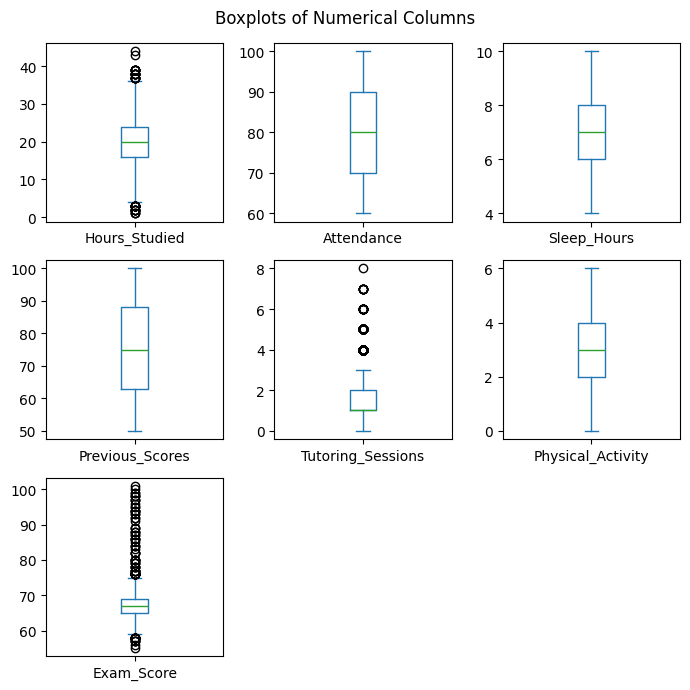

In [25]:
## Bxoplots for checking outliers
numerical_cols[[c for c in numerical_cols.columns]].plot(kind= 'box', 
                                                         figsize= (7,7), 
                                                         subplots= True, 
                                                         layout= (3,3), title= 'Boxplots of Numerical Columns')
plt.tight_layout()

### Data Preprocessing
Prior to preprocessing, we split the data into training, validation (if the data is sufficient enough) and testing sets.

In [26]:
## Predictors and target variable
X= students.drop(columns= 'Exam_Score')
y= students['Exam_Score']

## Data splitting (training and testing sets)
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size= 0.2, 
                                                   shuffle= True, random_state= seed)

## Training & validation sets
X_train, X_val, y_train, y_val= train_test_split(X_train, y_train, test_size= 0.15, 
                                                 shuffle= True, random_state= 42)

## Print out data shapes
for i in ['X_train', 'y_train', 'X_val', 'y_val', 'X_test', 'y_test']:
    if i in globals():
        print(f'{i} Shape: {globals()[i].shape}')

X_train Shape: (4492, 19)
y_train Shape: (4492,)
X_val Shape: (793, 19)
y_val Shape: (793,)
X_test Shape: (1322, 19)
y_test Shape: (1322,)


We then group the columns for the specific preprocessing task. 

In [27]:
## Dealing with ordinal columns (we have to manually map the order of each category from one extreme to the other, eg- Least to most)
ordinal_cols= {'Parental_Involvement': ['Low', 'Medium', 'High'],
                     'Access_to_Resources': ['Low', 'Medium', 'High'],
                     'Motivation_Level': ['Low', 'Medium', 'High'],
                     'Family_Income': ['Low', 'Medium', 'High'],
                     'Teacher_Quality': ['Low', 'Medium', 'High'],  # has NaN
                     'Parental_Education_Level': ['High School', 'College', 'Postgraduate'],  # has NaN
                     'Distance_from_Home': ['Near', 'Moderate', 'Far'],  # has NaN
                     'Peer_Influence': ['Negative', 'Neutral', 'Positive']
                    }

## We then save the ordinal column names in the above dictionary to a list

## Binary columns
binary_cols= ['Extracurricular_Activities',  # Yes/No
              'Internet_Access',             # Yes/No
              'Learning_Disabilities',       # Yes/No
              'School_Type',                 # Public/Private
              'Gender',                      # Male/Female
             ]

## Normal and non-normal numerical columns
numerical_cols_normal= ['Hours_Studied', 'Sleep_Hours', 'Physical_Activity']
numerical_cols_non_normal= ['Attendance', 'Tutoring_Sessions', 'Previous_Scores']

In [28]:
## Preprocessing pipeline
numerical_pipeline_normal= Pipeline([('imputer', SimpleImputer(strategy= 'mean')),
                                      ('z_score_scaler', StandardScaler())])

numerical_pipeline_non_normal= Pipeline([('imputer', SimpleImputer(strategy= 'mean')), 
                                         ('MinMax_scaler', MinMaxScaler())])

## We create a way to loop through the dictionary of ordinal categories
ordinal_categories= [ordinal_cols[c] for c in ordinal_cols.keys()]
ordinal_pipeline= Pipeline([('imputer', SimpleImputer(strategy= 'most_frequent')), 
                            ('encoder', OrdinalEncoder(categories= ordinal_categories, 
                                                       handle_unknown= 'use_encoded_value', unknown_value= -1))])


binary_pipeline= Pipeline([('imputer', SimpleImputer(strategy= 'most_frequent')),
                           ('encoder', OrdinalEncoder())])

## Combiining the pipeline
preprocessor= ColumnTransformer([('numerical_normal', numerical_pipeline_normal, numerical_cols_normal),
                                 ('numeric_non_normal', numerical_pipeline_non_normal, numerical_cols_non_normal),
                                 ('ordinal', ordinal_pipeline, list(ordinal_cols.keys())), # The pipeline only accepts a list of strings 
                                 ('binary', binary_pipeline, binary_cols)], 
                                 remainder= 'passthrough') # Appends untransformed columns to the end of the transformed output 

## Fitting on training data, transforming on validation and testing data
X_train_transformed= preprocessor.fit_transform(X_train)
X_val_transformed= preprocessor.transform(X_val)
X_test_transformed= preprocessor.transform(X_test)

## Preserve feature names for interpretability
# State the feature names in the same order you defined them in the pipeline
feature_names= numerical_cols_normal + numerical_cols_non_normal + list(ordinal_cols.keys()) + binary_cols

X_train_df= pd.DataFrame(X_train_transformed, columns= feature_names)
X_val_df= pd.DataFrame(X_val_transformed, columns= feature_names)
X_test_df= pd.DataFrame(X_test_transformed, columns= feature_names)

print(f'Feature matrix shape: {X_train_df.shape}')
X_train_df.head()

Feature matrix shape: (4492, 19)


,Hours_Studied,Sleep_Hours,Physical_Activity,Attendance,Tutoring_Sessions,Previous_Scores,Parental_Involvement,Access_to_Resources,Motivation_Level,Family_Income,Teacher_Quality,Parental_Education_Level,Distance_from_Home,Peer_Influence,Extracurricular_Activities,Internet_Access,Learning_Disabilities,School_Type,Gender
0,0.992388,-2.084276,-0.940410,0.600,0.375,0.24,0.0,2.0,1.0,2.0,2.0,0.0,0.0,2.0,0.0,0.0,0.0,1.0,1.0
1,0.001874,0.666589,1.000915,0.600,0.000,0.36,2.0,1.0,1.0,0.0,1.0,2.0,0.0,2.0,1.0,1.0,0.0,0.0,1.0
2,0.827302,0.666589,1.000915,0.825,0.000,0.16,2.0,1.0,1.0,2.0,1.0,0.0,1.0,2.0,0.0,1.0,0.0,0.0,0.0
3,0.001874,1.354305,0.030252,0.950,0.000,0.04,2.0,2.0,1.0,1.0,1.0,1.0,2.0,2.0,1.0,1.0,0.0,0.0,1.0
4,-1.483896,1.354305,0.030252,0.725,0.125,0.52,1.0,0.0,1.0,1.0,2.0,2.0,2.0,1.0,1.0,1.0,0.0,1.0,1.0


While we transformed the predictor variables, for linear models and neural networks, if the target variable is roughly normal (as it is in our case; see above distribution plots) we leave it as is. If skewed, then we transform it to follow a normal distribution via either of the below methods:
- Log transformation (best for values of very large magnitude and non-linear relationships)
$$log_{b}(a)= x \quad \text{if} \quad b^x = a$$
- Power transformation (similar to log transformation, but implements a custom power function/exponent $x$)
  - Box-Cox Transformation (for strictly positive values) ($x > 0$)
  - Yeo-Johnson Transformation (can support all values of $x$)


We also perform a correlation check from which we expect `Hours_Studied` and `Attendance` that show the strongest positive correlations with `Exam_Score` to influence the target variable's prediction. 

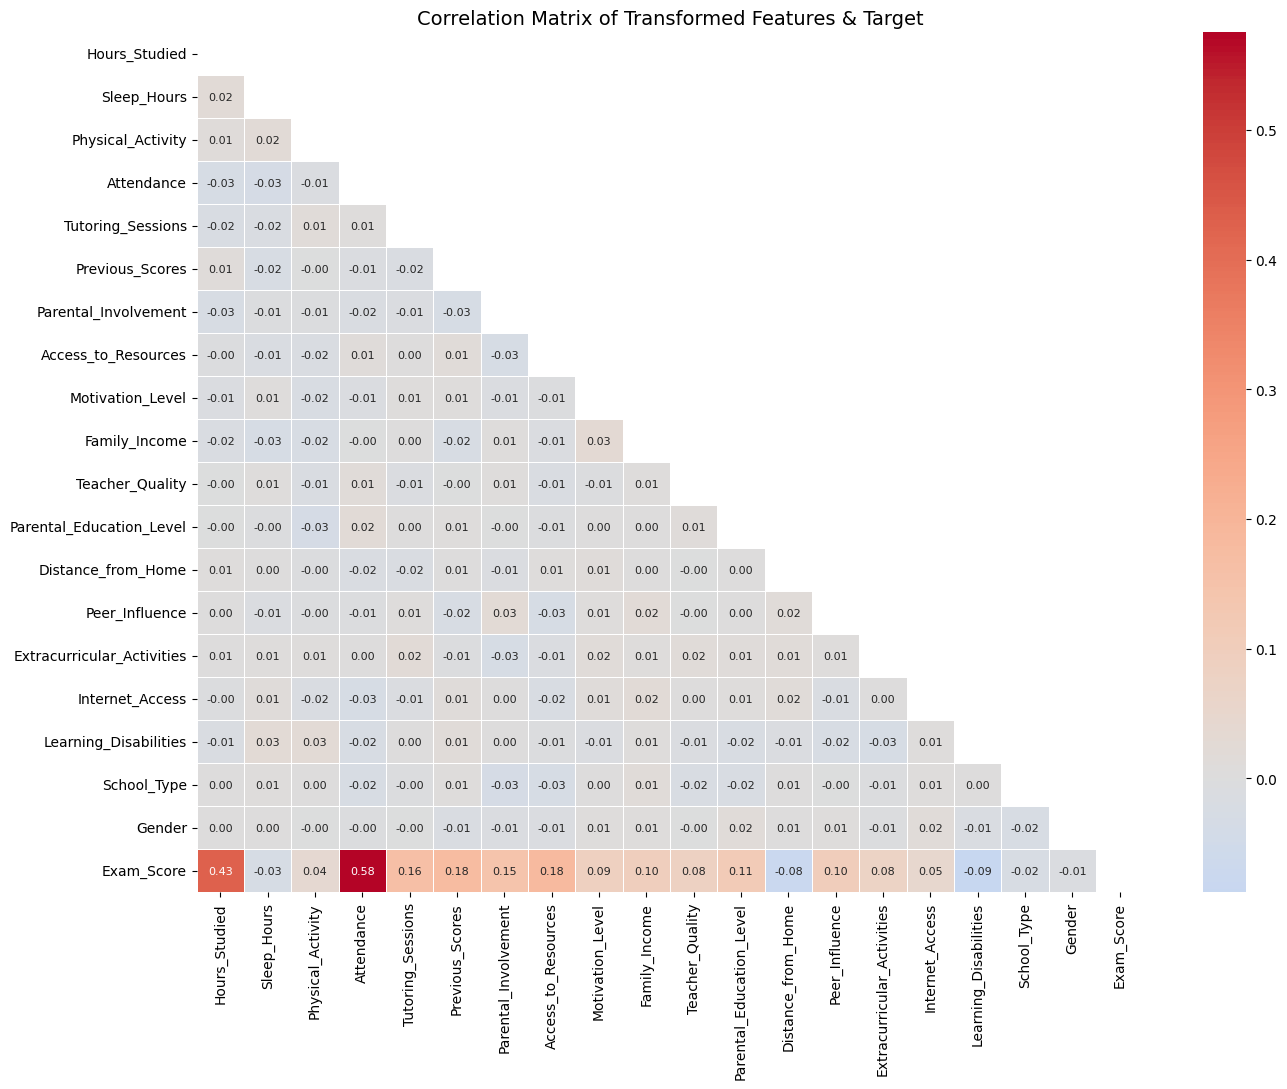

In [29]:
## Correlation heatmap
corr_students= X_train_df.copy()
corr_students['Exam_Score']= y_train.values

corr_matrix= corr_students.corr()

fig, ax= plt.subplots(figsize=(14, 11))
mask= np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.4,
    annot_kws={'size': 8}, ax=ax)

ax.set_title('Correlation Matrix of Transformed Features & Target', fontsize=14)
plt.tight_layout()

### Linear Regression (PyTorch)
We use `torch.nn.Linear` to perform the regression task. It is a neural network layer that performs a linear transformation on input data. While it is related to linear regression, on its own, it's not the same thing as a full linear regression model.

`nn.Linear` applies the following linear equation:
$$y= xW^T + b$$
where:
- $y$ is the output
- $x$ is the input vector
- $W$ is the weight matrix
- $b$ is the bias vector
- $W^T$ represents matrix multiplication between the input vector and the transposed weight matrix $[x_1w_{11} + x_2w_{21}+ ...+ x_nw_{nn}]$

The output then proceeds to the next neural network layer or becomes the final output of the model (it can also have multiple outputs $[y_1, y_2, \dots, y_n]$). Linear regression in contrast, is when the layer is combined with a mean squared error loss function (and an optimizer) for training at which point `nn.linear` is no longer a neural network layer but becomes a linear regression model.

In [30]:
## Linear Regression model
class MultipleLinearRegression(nn.Module):
    def __init__(self, in_features: int, out_features: int):
        super().__init__()
        self.linear= nn.Linear(in_features= in_features, 
                               out_features= out_features)
    
    def forward(self, x:torch.Tensor) -> torch.Tensor:
        return self.linear(x) # Computes the linear transformation xW + b
    
linear_model= MultipleLinearRegression(in_features= X_train_transformed.shape[1], # No. of features 
                                out_features= 1)


torch.manual_seed(seed) # For reproducibility
print(linear_model) # The contructed model
print(f'\n{linear_model.state_dict()}') # Model parameters (initial parameter values are random)
        

MultipleLinearRegression(
  (linear): Linear(in_features=19, out_features=1, bias=True)
)

OrderedDict({'linear.weight': tensor([[ 0.1754,  0.1904, -0.0537,  0.2107, -0.0503,  0.0463, -0.1117,  0.1347,
          0.2022, -0.1683,  0.1994,  0.0429,  0.1695,  0.0311,  0.1106, -0.0324,
          0.1769,  0.0339, -0.1071]]), 'linear.bias': tensor([0.0585])})


We the select the loss function and optimizer. We will apply mean squared error (MSE) as our loss function in conjunction with the Stochastic Gradient Descent`SGD` optimizer. Both are preferred hand-in-hand as:
- MSE penalizes large errors heavily
- SGD is a gradient-based optimizer. MSE produces a smoother gradient than other errors (eg- mean absolute error/L1 loss) that makes it easier for SGD to follow

In [31]:
## Loss function
loss_fn= nn.MSELoss()

## Optimizer
optimizer= torch.optim.SGD(params= linear_model.parameters(), 
                           lr= 0.01/2)

In [32]:
## Comvert numpy arrays to tensors
# Datatype used is float32 since deep learning layers in PyTorch typically use float32 for speed and GPU compatibility
X_train_tensor= torch.from_numpy(X_train_transformed).type(torch.float32)
X_val_tensor= torch.from_numpy(X_val_transformed).type(torch.float32)
X_test_tensor= torch.from_numpy(X_test_transformed).type(torch.float32)
y_train_tensor= torch.from_numpy(np.array(y_train).reshape(-1,1)).type(torch.float32)
y_val_tensor= torch.from_numpy(np.array(y_val).reshape(-1,1)).type(torch.float32)
y_test_tensor= torch.from_numpy(np.array(y_test).reshape(-1,1)).type(torch.float32)

## Lists to store loss values for tracking
epoch_count= []
train_loss_values= []
val_loss_values= []

## Training loop
epochs= 30000

for ep in range(epochs):
    ## Training mode
    linear_model.train()

    # Forward pass
    y_train_pred= linear_model.forward(X_train_tensor)

    # Training loss
    train_loss= loss_fn(y_train_pred, y_train_tensor)

    # Reset gradients to zero
    optimizer.zero_grad()

    # Backpropagation
    train_loss.backward()

    # Update weight and bias parameters (via gradient descent)
    optimizer.step()

    ## Model validation
    linear_model.eval()
    with torch.inference_mode():
        y_val_pred= linear_model.forward(X_val_tensor)
        val_loss= loss_fn(y_val_pred, y_val_tensor)

    
    # Print out model parameters(after n training and validation loops)
    if ep % 1000== 0:
        print(f'---' * 30)
        print(f'Epoch {ep}')
        print(f'Training Loss: {train_loss}')
        print(f'Validation Loss: {val_loss}')
        print(f'{linear_model.state_dict()}')
        
        # Save loss values
        epoch_count.append(ep)
        train_loss_values.append(train_loss)
        val_loss_values.append(val_loss)


------------------------------------------------------------------------------------------
Epoch 0
Training Loss: 4445.86767578125
Validation Loss: 3508.189208984375
OrderedDict({'linear.weight': tensor([[ 0.1904,  0.1874, -0.0517,  0.5492,  0.0747,  0.3823,  0.6178,  0.8687,
          0.8057,  0.3581,  1.0019,  0.5052,  0.5014,  0.8253,  0.5110,  0.5818,
          0.2480,  0.4964,  0.2789]]), 'linear.bias': tensor([0.7242])})
------------------------------------------------------------------------------------------
Epoch 1000
Training Loss: 39.94995880126953
Validation Loss: 44.35009002685547
OrderedDict({'linear.weight': tensor([[1.8576e+00, 3.8226e-03, 4.0445e-01, 1.0280e+01, 3.8498e+00, 7.0003e+00,
         3.5825e+00, 3.8219e+00, 2.3877e+00, 1.7717e+00, 4.2448e+00, 1.6008e+00,
         5.7316e-01, 2.6967e+00, 3.3964e+00, 1.1058e+01, 9.3510e-01, 4.2224e+00,
         2.7575e+00]]), 'linear.bias': tensor([18.7292])})
-------------------------------------------------------------------

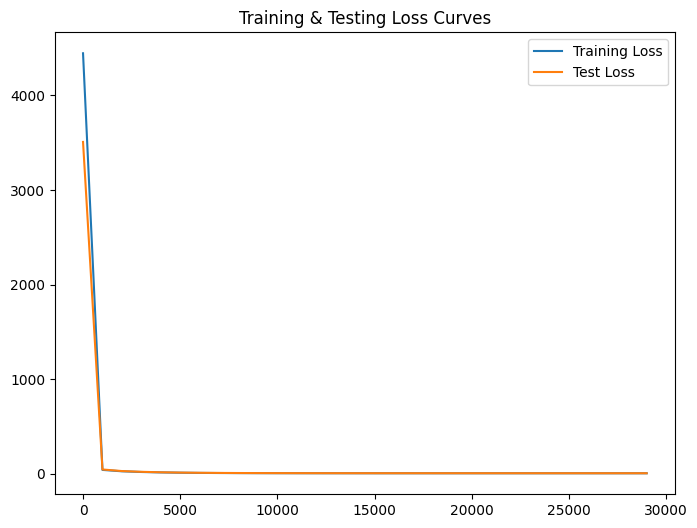

In [36]:
## Visualize the loss function
plt.figure(figsize= (8,6))
plt.plot(epoch_count, torch.tensor(train_loss_values).detach().numpy(), label= 'Training Loss')
plt.plot(epoch_count, torch.tensor(val_loss_values).numpy(), label= 'Test Loss')
 # We convert the tensor data into numpy arrays as Matplotlib cannot plot tensor data

plt.title('Training & Testing Loss Curves')
plt.legend()

Seeing we have acceptable training and validation results based on the above plot that shows model convergence as well as the low loss values, we can perform a final evaluation to assess how the model performs on unseen data.

In [ ]:
## Final evaluation
with torch.inference_mode():
    y_pred_final_torch= linear_model.forward(X_test_tensor)

torch_lr_rmse= root_mean_squared_error(y_test, y_pred_final_torch)
torch_lr_mae= mean_absolute_error(y_test, y_pred_final_torch)
torch_lr_r2= r2_score(y_test, y_pred_final_torch)

print(f"PyTorch LR — RMSE: {torch_lr_rmse:.4f}  MAE: {torch_lr_mae:.4f}  R²: {torch_lr_r2:.4f}")

PyTorch LR — RMSE: 1.8025  MAE: 0.4452  R²: 0.7701


### Further Tasks
While model performance is reasonable, it could be improved via feature selection methods to eliminate irrelevant features (e.g.- Recursive Feature Elimination, Lasso and/or Ridge regression). 

Performance can also be compared to other models (e.g- XGBoost, Tree-based models, neural networks, etc.)
